# ARX Baseline V5

V5 giữ nguyên V4 nhưng mở rộng input từ 6 biến gốc lên 16 feature:

- `ARX(2,2,1)`
- 6 input gốc + 10 feature engineer
- Ridge
- không Lasso
- không clip free-run
- z-score normalization bằng thống kê train
- `include_intercept=True`


## 1. Import và cấu hình

Notebook có thể chạy từ project root hoặc từ thư mục `ARX_Model_Version`.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = Path.cwd()
PROJECT_ROOT = WORK_DIR.parent if WORK_DIR.name == "ARX_Model_Version" else WORK_DIR
VERSION_DIR = PROJECT_ROOT / "ARX_Model_Version"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from arx_pipeline import (
    DataConfig,
    SplitConfig,
    ModelConfig,
    load_or_generate_data,
    split_time_series,
    summarize_dataset_behavior,
    build_regression_matrix,
    estimate_ols,
    build_true_theta,
    evaluate_slice,
    summarize_parameters,
    compute_ar_roots,
    compute_metrics,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## 2. Cấu hình V5


In [2]:
DATA_CONFIG = DataConfig(
    csv_path=PROJECT_ROOT / "greenhouse_data.csv",
    generator_script_path=PROJECT_ROOT / "data_generator.py",
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
)

SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)

BASELINE_INPUT_COLS = (
    "Temperature",
    "Humidity",
    "Light",
    "Drip",
    "Mist",
    "Fan",
)

AUGMENTED_INPUT_COLS = (
    *BASELINE_INPUT_COLS,
    "Light_log",
    "Temp_x_Humi",
    "Temp_x_Light",
    "Humi_x_Light",
    "SP_Center",
    "SP_Width",
    "Month_sin",
    "Month_cos",
    "Season_sin",
    "Season_cos",
)

V5_CONFIG = ModelConfig(
    na=2,
    nb=2,
    nk=1,
    include_intercept=True,
    input_cols=AUGMENTED_INPUT_COLS,
    output_col="Soil_Moisture",
    simulation_clip=None,
)

SCALE_COLS = ("Soil_Moisture", *AUGMENTED_INPUT_COLS)
RIDGE_ALPHAS = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
V5_CONFIG


ModelConfig(na=2, nb=2, nk=1, include_intercept=True, input_cols=('Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan', 'Light_log', 'Temp_x_Humi', 'Temp_x_Light', 'Humi_x_Light', 'SP_Center', 'SP_Width', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos'), output_col='Soil_Moisture', simulation_clip=None)

## 3. Load data và chia train/validation/test


In [3]:
df_full, true_params, data_source = load_or_generate_data(DATA_CONFIG)
df_train, df_val, df_test = split_time_series(df_full, SPLIT_CONFIG)

overview = pd.DataFrame([
    summarize_dataset_behavior(df_full, "Full"),
    summarize_dataset_behavior(df_train, "Train"),
    summarize_dataset_behavior(df_val, "Validation"),
    summarize_dataset_behavior(df_test, "Test"),
])

print("Nguồn dữ liệu:", data_source)
print("Số dòng:", len(df_full), "| Train:", len(df_train), "| Validation:", len(df_val), "| Test:", len(df_test))
overview


Nguồn dữ liệu: CSV:greenhouse_data.csv
Số dòng: 105120 | Train: 63072 | Validation: 21024 | Test: 21024


,label,rows,timestamp_start,timestamp_end,months_present,seasons_present,drip_on_pct,drip_switches,mist_on_pct,mist_switches,fan_on_pct,fan_switches,below_sp_pct,inside_sp_pct,above_sp_pct
0,Full,105120,2025-01-01 00:00:00,2025-12-31 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[autumn, spring, summer, winter]",22.80,12533,7.89,8022,16.89,12768,23.09,76.35,0.56
1,Train,63072,2025-01-01 00:00:00,2025-08-07 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8]","[spring, summer, winter]",22.95,7546,7.81,4760,17.46,7865,23.30,76.13,0.57
2,Validation,21024,2025-08-08 00:00:00,2025-10-19 23:55:00,"[8, 9, 10]","[autumn, summer]",23.47,2558,9.77,1970,19.34,2817,23.84,75.75,0.41
3,Test,21024,2025-10-20 00:00:00,2025-12-31 23:55:00,"[10, 11, 12]","[autumn, winter]",21.68,2429,6.25,1292,12.75,2085,21.70,77.61,0.69


## 4. Tạo augmented features


In [4]:
def build_augmented_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df["Light_log"] = np.log1p(df["Light"].clip(lower=0))
    df["Temp_x_Humi"] = df["Temperature"] * df["Humidity"]
    df["Temp_x_Light"] = df["Temperature"] * df["Light_log"]
    df["Humi_x_Light"] = df["Humidity"] * df["Light_log"]
    df["SP_Center"] = 0.5 * (df["Soil_Low_SP"] + df["Soil_High_SP"])
    df["SP_Width"] = df["Soil_High_SP"] - df["Soil_Low_SP"]
    df["Month_sin"] = np.sin(2.0 * np.pi * df["Month"] / 12.0)
    df["Month_cos"] = np.cos(2.0 * np.pi * df["Month"] / 12.0)

    season_map = {"spring": 0, "summer": 1, "autumn": 2, "winter": 3}
    season_num = df["Season"].map(season_map).fillna(0).astype(float)
    df["Season_sin"] = np.sin(2.0 * np.pi * season_num / 4.0)
    df["Season_cos"] = np.cos(2.0 * np.pi * season_num / 4.0)
    return df


df_full_aug = build_augmented_df(df_full)
df_train_aug, df_val_aug, df_test_aug = split_time_series(df_full_aug, SPLIT_CONFIG)

display(df_train_aug[list(AUGMENTED_INPUT_COLS)].head())
display(df_train_aug[list(AUGMENTED_INPUT_COLS)].describe().T.round(4))


,Temperature,Humidity,Light,Drip,Mist,Fan,Light_log,Temp_x_Humi,Temp_x_Light,Humi_x_Light,SP_Center,SP_Width,Month_sin,Month_cos,Season_sin,Season_cos
0,20.778462,83.333673,1.168667,0.0,0.0,0.0,0.774113,1731.545561,16.084869,64.509646,55.5,9.0,0.5,0.866025,-1.0,-1.836970e-16
1,19.725025,82.264886,2.256788,0.0,0.0,0.0,1.180741,1622.676903,23.290155,97.133564,55.5,9.0,0.5,0.866025,-1.0,-1.836970e-16
2,19.696345,82.314817,20.575650,0.0,0.0,0.0,3.071565,1621.301048,60.498612,252.835341,55.5,9.0,0.5,0.866025,-1.0,-1.836970e-16
3,19.701227,82.287578,25.108612,0.0,0.0,0.0,3.262265,1621.166241,64.270627,268.443904,55.5,9.0,0.5,0.866025,-1.0,-1.836970e-16
4,19.837379,83.482156,7.002633,0.0,0.0,0.0,2.079771,1656.067143,41.257198,173.623737,55.5,9.0,0.5,0.866025,-1.0,-1.836970e-16


,count,mean,std,min,25%,50%,75%,max
Temperature,63072.0,25.6598,3.5783,14.0000,23.6918,26.9788,28.2897,32.2487
Humidity,63072.0,73.4929,8.0722,30.0000,68.3896,74.4612,80.0941,92.6823
Light,63072.0,288.8826,344.2494,0.0000,9.5448,28.0561,605.8062,1182.9120
Drip,63072.0,0.2295,0.4205,0.0000,0.0000,0.0000,0.0000,1.0000
Mist,63072.0,0.0781,0.2684,0.0000,0.0000,0.0000,0.0000,1.0000
Fan,63072.0,0.1746,0.3796,0.0000,0.0000,0.0000,0.0000,1.0000
Light_log,63072.0,4.0854,2.2292,0.0000,2.3556,3.3692,6.4082,7.0766
Temp_x_Humi,63072.0,1868.0324,230.6536,823.8717,1736.9118,1899.8808,2024.5137,2560.8206
Temp_x_Light,63072.0,109.0666,65.8807,0.0000,53.5662,88.9817,177.8426,217.7655
Humi_x_Light,63072.0,291.6350,151.8776,0.0000,179.4289,262.8555,434.1991,607.7281


## 5. Tính z-score từ train

Mean/std chỉ lấy từ train để tránh leakage sang validation/test.


In [5]:
scale_stats = {}
for col in SCALE_COLS:
    mean = float(df_train_aug[col].astype(float).mean())
    std = float(df_train_aug[col].astype(float).std(ddof=0))
    if not np.isfinite(std) or std < 1e-12:
        std = 1.0
    scale_stats[col] = {"mean": mean, "std": std}

pd.DataFrame(scale_stats).T


,mean,std
Soil_Moisture,57.468777,3.353448
Temperature,25.659789,3.578281
Humidity,73.492878,8.072112
Light,288.882555,344.246625
Drip,0.229484,0.420501
Mist,0.078133,0.268381
Fan,0.174610,0.379633
Light_log,4.085438,2.229150
Temp_x_Humi,1868.032414,230.651722
Temp_x_Light,109.066596,65.880210


In [6]:
def apply_zscore(df_in: pd.DataFrame, stats: dict[str, dict[str, float]]) -> pd.DataFrame:
    df_out = df_in.copy()
    for col, st in stats.items():
        df_out[col] = (df_out[col].astype(float) - st["mean"]) / st["std"]
    return df_out


def inverse_y(values: np.ndarray) -> np.ndarray:
    st = scale_stats["Soil_Moisture"]
    return np.asarray(values, dtype=float) * st["std"] + st["mean"]


df_train_z = apply_zscore(df_train_aug, scale_stats)
df_val_z = apply_zscore(df_val_aug, scale_stats)
df_test_z = apply_zscore(df_test_aug, scale_stats)

display(df_train_z[["Soil_Moisture", *AUGMENTED_INPUT_COLS]].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture,63072.0,-0.0,1.0,-2.6108,-0.7291,-0.0101,0.7299,3.7232
Temperature,63072.0,0.0,1.0,-3.2585,-0.5500,0.3686,0.7350,1.8414
Humidity,63072.0,-0.0,1.0,-5.3880,-0.6322,0.1200,0.8178,2.3772
Light,63072.0,0.0,1.0,-0.8392,-0.8114,-0.7577,0.9206,2.5971
Drip,63072.0,-0.0,1.0,-0.5457,-0.5457,-0.5457,-0.5457,1.8324
Mist,63072.0,0.0,1.0,-0.2911,-0.2911,-0.2911,-0.2911,3.4349
Fan,63072.0,-0.0,1.0,-0.4599,-0.4599,-0.4599,-0.4599,2.1742
Light_log,63072.0,-0.0,1.0,-1.8327,-0.7760,-0.3213,1.0420,1.3418
Temp_x_Humi,63072.0,-0.0,1.0,-4.5270,-0.5685,0.1381,0.6784,3.0036
Temp_x_Light,63072.0,0.0,1.0,-1.6555,-0.8424,-0.3049,1.0440,1.6499


## 6. Tạo regression matrix trên dữ liệu đã normalize


In [7]:
X_train_z, y_train_z = build_regression_matrix(df_train_z, V5_CONFIG)
theta_ols_z, cov_ols_z, sigma2_ols_z = estimate_ols(X_train_z, y_train_z)
true_theta = build_true_theta(true_params, V5_CONFIG)

matrix_info = pd.Series({
    "x_train_shape": X_train_z.shape,
    "y_train_shape": y_train_z.shape,
    "rank_x_train": int(np.linalg.matrix_rank(X_train_z)),
    "condition_number_xtx": float(np.linalg.cond(X_train_z.T @ X_train_z)),
    "sigma2_ols_scaled": float(sigma2_ols_z),
})

matrix_info


x_train_shape                       (63070, 35)
y_train_shape                          (63070,)
rank_x_train                                 33
condition_number_xtx    613779725192361934848.0
sigma2_ols_scaled                      0.005555
dtype: object

## 7. Ridge alpha search


In [8]:
def estimate_ridge(x_mat: np.ndarray, y_vec: np.ndarray, alpha: float, penalize_intercept: bool = False) -> np.ndarray:
    n_params = x_mat.shape[1]
    penalty = np.eye(n_params, dtype=float)
    if not penalize_intercept and V5_CONFIG.include_intercept:
        penalty[-1, -1] = 0.0
    return np.linalg.pinv(x_mat.T @ x_mat + float(alpha) * penalty) @ x_mat.T @ y_vec


def ridge_sigma2(x_mat: np.ndarray, y_vec: np.ndarray, theta: np.ndarray) -> float:
    resid = y_vec - x_mat @ theta
    return float(np.dot(resid, resid) / max(1, len(y_vec) - len(theta)))


def real_unit_metrics_for_theta(theta: np.ndarray, split_name: str, df_z: pd.DataFrame, mode: str) -> dict[str, float]:
    ev = evaluate_slice(split_name, df_z, theta, V5_CONFIG, true_theta=true_theta, n_step=12)
    arrays = ev["arrays"]
    if mode == "1step":
        y_true = inverse_y(arrays["y_true_1step"])
        y_pred = inverse_y(arrays["y_pred_1step"])
    elif mode == "12step":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_n_step"])
    elif mode == "sim":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_sim"])
    else:
        raise ValueError(mode)
    return compute_metrics(y_true, y_pred, len(theta))


search_rows = []
theta_by_alpha = {}
for alpha in RIDGE_ALPHAS:
    theta = theta_ols_z if alpha == 0.0 else estimate_ridge(X_train_z, y_train_z, alpha)
    theta_by_alpha[float(alpha)] = theta
    train_sim = real_unit_metrics_for_theta(theta, "Train", df_train_z, "sim")
    val_1 = real_unit_metrics_for_theta(theta, "Validation", df_val_z, "1step")
    val_12 = real_unit_metrics_for_theta(theta, "Validation", df_val_z, "12step")
    val_sim = real_unit_metrics_for_theta(theta, "Validation", df_val_z, "sim")
    test_sim = real_unit_metrics_for_theta(theta, "Test", df_test_z, "sim")
    search_rows.append({
        "alpha": float(alpha),
        "train_FIT_sim": train_sim["FIT"],
        "val_FIT_1step": val_1["FIT"],
        "val_FIT_12step": val_12["FIT"],
        "val_FIT_sim": val_sim["FIT"],
        "val_RMSE_sim": val_sim["RMSE"],
        "test_FIT_sim": test_sim["FIT"],
        "test_RMSE_sim": test_sim["RMSE"],
        "theta_l2": float(np.linalg.norm(theta)),
    })

alpha_search_df = pd.DataFrame(search_rows).sort_values(
    ["val_FIT_sim", "val_FIT_12step", "val_FIT_1step"],
    ascending=[False, False, False],
).reset_index(drop=True)

best_alpha = float(alpha_search_df.iloc[0]["alpha"])
theta_hat_z = theta_by_alpha[best_alpha]
sigma2_hat_z = ridge_sigma2(X_train_z, y_train_z, theta_hat_z)

alpha_search_df.round(6)


,alpha,train_FIT_sim,val_FIT_1step,val_FIT_12step,val_FIT_sim,val_RMSE_sim,test_FIT_sim,test_RMSE_sim,theta_l2
0,0.000000,49.586525,91.634515,72.934156,37.914544,1.863875,41.189946,1.712945,1.031788
1,0.000001,49.586525,91.634515,72.934156,37.914544,1.863875,41.189946,1.712945,1.031788
2,0.000010,49.586525,91.634515,72.934156,37.914543,1.863875,41.189946,1.712945,1.031787
3,0.000100,49.586519,91.634515,72.934156,37.914534,1.863875,41.189940,1.712945,1.031783
4,0.001000,49.586467,91.634516,72.934156,37.914442,1.863878,41.189882,1.712946,1.031741
5,0.010000,49.585941,91.634527,72.934156,37.913530,1.863905,41.189302,1.712963,1.031324
6,0.100000,49.580620,91.634622,72.934127,37.904571,1.864174,41.183456,1.713134,1.027653
7,1.000000,49.526879,91.635190,72.933337,37.824533,1.866577,41.124047,1.714864,1.012444
8,10.000000,49.026323,91.635579,72.930602,37.151987,1.886768,40.524307,1.732333,1.000730
9,100.000000,44.484218,91.598383,72.893476,30.853179,2.075865,34.758376,1.900275,0.970618


## 8. Bảng tham số scaled của alpha tốt nhất


In [9]:
best_summary_df = pd.DataFrame({
    "name": V5_CONFIG.param_names,
    "theta_scaled": theta_hat_z,
    "abs_theta_scaled": np.abs(theta_hat_z),
})
print("Best alpha:", best_alpha)
best_summary_df


Best alpha: 0.0


,name,theta_scaled,abs_theta_scaled
0,a1,9.630370e-01,9.630370e-01
1,a2,2.682903e-02,2.682903e-02
2,b_Temperature_1,-2.648947e-03,2.648947e-03
3,b_Temperature_2,-2.179938e-02,2.179938e-02
4,b_Humidity_1,1.423397e-02,1.423397e-02
5,b_Humidity_2,-1.467772e-02,1.467772e-02
6,b_Light_1,-1.108648e-02,1.108648e-02
7,b_Light_2,-2.370846e-02,2.370846e-02
8,b_Drip_1,1.569114e-01,1.569114e-01
9,b_Drip_2,2.321873e-01,2.321873e-01


## 9. Đánh giá Train / Validation / Test

FIT không đổi theo phép đổi đơn vị tuyến tính, nhưng RMSE được báo lại theo đơn vị `Soil_Moisture` thật.


In [10]:
train_eval_z = evaluate_slice("Train", df_train_z, theta_hat_z, V5_CONFIG, true_theta=true_theta, n_step=12)
val_eval_z = evaluate_slice("Validation", df_val_z, theta_hat_z, V5_CONFIG, true_theta=true_theta, n_step=12)
test_eval_z = evaluate_slice("Test", df_test_z, theta_hat_z, V5_CONFIG, true_theta=true_theta, n_step=12)


def real_unit_metrics(ev: dict, mode: str) -> dict[str, float]:
    arrays = ev["arrays"]
    if mode == "1step":
        y_true = inverse_y(arrays["y_true_1step"])
        y_pred = inverse_y(arrays["y_pred_1step"])
    elif mode == "12step":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_n_step"])
    elif mode == "sim":
        y_true = inverse_y(arrays["y_true_sim"])
        y_pred = inverse_y(arrays["y_pred_sim"])
    else:
        raise ValueError(mode)
    return compute_metrics(y_true, y_pred, len(theta_hat_z))


def metric_row(split_name: str, ev: dict) -> dict[str, float | str]:
    m1 = real_unit_metrics(ev, "1step")
    m12 = real_unit_metrics(ev, "12step")
    msim = real_unit_metrics(ev, "sim")
    return {
        "split": split_name,
        "FIT_1step": m1["FIT"],
        "RMSE_1step": m1["RMSE"],
        "FIT_12step": m12["FIT"],
        "RMSE_12step": m12["RMSE"],
        "FIT_sim": msim["FIT"],
        "RMSE_sim": msim["RMSE"],
        "Bias_sim": msim["Bias"],
    }


metrics_df = pd.DataFrame([
    metric_row("Train", train_eval_z),
    metric_row("Validation", val_eval_z),
    metric_row("Test", test_eval_z),
]).round(4)

metrics_df


,split,FIT_1step,RMSE_1step,FIT_12step,RMSE_12step,FIT_sim,RMSE_sim,Bias_sim
0,Train,92.5489,0.2499,76.4601,0.7894,49.5865,1.6906,0.0049
1,Validation,91.6345,0.2511,72.9342,0.8125,37.9145,1.8639,0.5810
2,Test,91.3461,0.2521,72.5934,0.7983,41.1899,1.7129,0.4831


## 10. So sánh với V1/V2/V3/V4 artifact


In [11]:
v1_path_candidates = [
    VERSION_DIR / "arx_baseline_v1.json",
    PROJECT_ROOT / "arx_baseline_v1.json",
]
v2_path_candidates = [
    VERSION_DIR / "arx_baseline_v2.json",
    PROJECT_ROOT / "arx_baseline_v2.json",
]
v3_path_candidates = [
    VERSION_DIR / "arx_baseline_v3.json",
    PROJECT_ROOT / "arx_baseline_v3.json",
]
v4_path_candidates = [
    VERSION_DIR / "arx_baseline_v4.json",
    PROJECT_ROOT / "arx_baseline_v4.json",
]
v1_artifact = None
for path in v1_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v1_artifact = json.load(f)
        break
v2_artifact = None
for path in v2_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v2_artifact = json.load(f)
        break
v3_artifact = None
for path in v3_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v3_artifact = json.load(f)
        break
v4_artifact = None
for path in v4_path_candidates:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            v4_artifact = json.load(f)
        break

if v1_artifact is None:
    comparison_df = pd.DataFrame()
else:
    rows = [
        {
            "version": "V1 raw OLS",
            "val_FIT_sim": v1_artifact["metrics"]["validation"]["fit_sim"],
            "test_FIT_sim": v1_artifact["metrics"]["test"]["fit_sim"],
        }
    ]
    if v2_artifact is not None:
        rows.append(
            {
                "version": "V2 z-score OLS",
                "val_FIT_sim": v2_artifact["metrics"]["validation"]["fit_sim"],
                "test_FIT_sim": v2_artifact["metrics"]["test"]["fit_sim"],
            }
        )
    if v3_artifact is not None:
        rows.append(
            {
                "version": "V3 z-score + intercept OLS",
                "val_FIT_sim": v3_artifact["metrics"]["validation"]["fit_sim"],
                "test_FIT_sim": v3_artifact["metrics"]["test"]["fit_sim"],
            }
        )
    if v4_artifact is not None:
        rows.append(
            {
                "version": f"V4 Ridge alpha={v4_artifact['regularization']['best_alpha']:g}",
                "val_FIT_sim": v4_artifact["metrics"]["validation"]["fit_sim"],
                "test_FIT_sim": v4_artifact["metrics"]["test"]["fit_sim"],
            }
        )
    rows.append(
        {
            "version": f"V5 augmented Ridge alpha={best_alpha:g}",
            "val_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Validation", "FIT_sim"].iloc[0]),
            "test_FIT_sim": float(metrics_df.loc[metrics_df["split"] == "Test", "FIT_sim"].iloc[0]),
        }
    )
    comparison_df = pd.DataFrame(rows)
    comparison_df["test_gain_vs_v1"] = comparison_df["test_FIT_sim"] - comparison_df.loc[0, "test_FIT_sim"]
    comparison_df["test_gain_vs_previous"] = comparison_df["test_FIT_sim"].diff()

comparison_df.round(4)


,version,val_FIT_sim,test_FIT_sim,test_gain_vs_v1,test_gain_vs_previous
0,V1 raw OLS,42.9588,43.8749,0.0000,NaN
1,V2 z-score OLS,42.4854,43.3983,-0.4767,-0.4767
2,V3 z-score + intercept OLS,42.4860,43.3988,-0.4762,0.0005
3,V4 Ridge alpha=0,42.4860,43.3988,-0.4762,0.0000
4,V5 augmented Ridge alpha=0,37.9145,41.1899,-2.6850,-2.2089


## 11. Vẽ free-run simulation


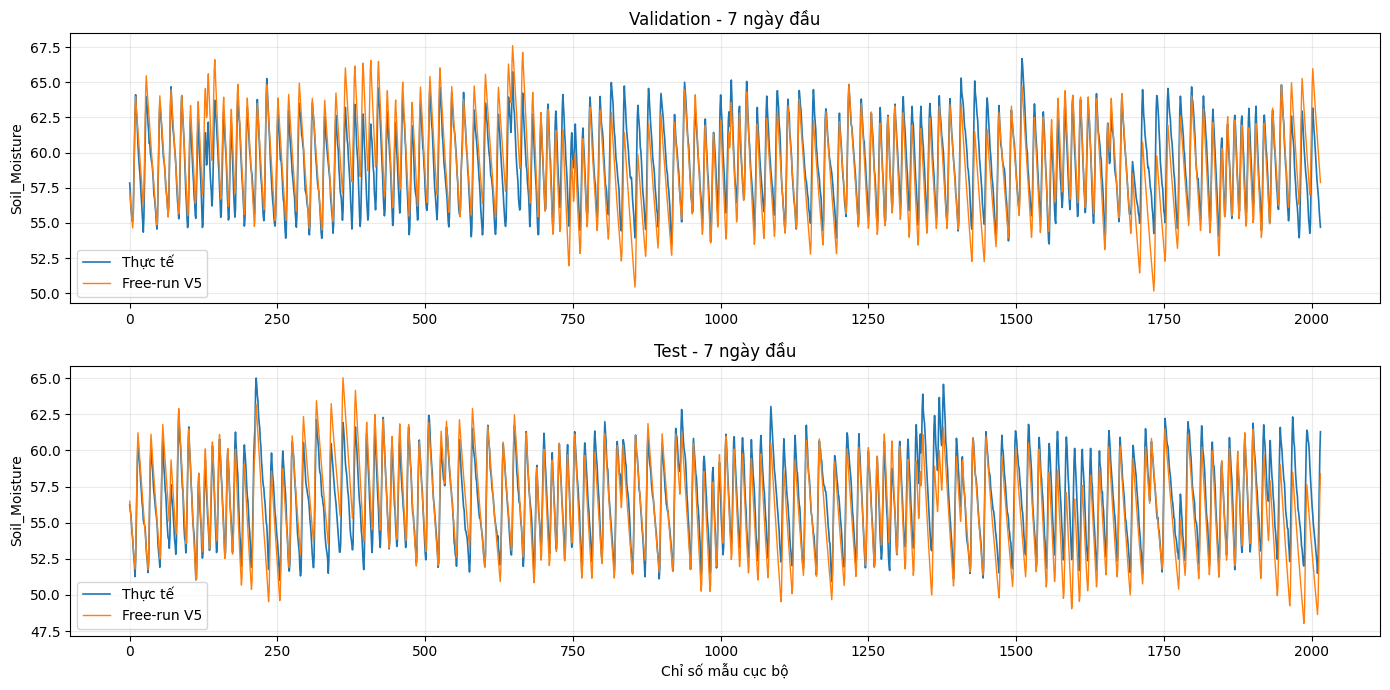

In [12]:
def prediction_frame_real(ev: dict, split_name: str) -> pd.DataFrame:
    arrays = ev["arrays"]
    n = len(arrays["y_true_sim"])
    return pd.DataFrame({
        "split": split_name,
        "idx": np.arange(n),
        "y_true": inverse_y(arrays["y_true_sim"]),
        "y_pred_sim": inverse_y(arrays["y_pred_sim"]),
        "y_pred_12step": inverse_y(arrays["y_pred_n_step"]),
    })


pred_val = prediction_frame_real(val_eval_z, "Validation")
pred_test = prediction_frame_real(test_eval_z, "Test")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, pred_df, title in [
    (axes[0], pred_val.iloc[: 7 * 24 * 12], "Validation - 7 ngày đầu"),
    (axes[1], pred_test.iloc[: 7 * 24 * 12], "Test - 7 ngày đầu"),
]:
    ax.plot(pred_df["idx"], pred_df["y_true"], label="Thực tế", linewidth=1.2)
    ax.plot(pred_df["idx"], pred_df["y_pred_sim"], label="Free-run V5", linewidth=1.0)
    ax.set_title(title)
    ax.set_ylabel("Soil_Moisture")
    ax.grid(True, alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Chỉ số mẫu cục bộ")
fig.tight_layout()
plt.show()


## 12. Stability roots


In [13]:
ar_roots = compute_ar_roots(theta_hat_z, V5_CONFIG)
pd.DataFrame(ar_roots)


,root_index,real,imag,magnitude
0,1,0.990133,0.0,0.990133
1,2,-0.027096,0.0,0.027096


## 13. Lưu artifact V5


In [14]:
def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, Path):
        return str(value)
    return value


artifact = {
    "model_type": "ARX",
    "version": "v5_augmented_zscore_intercept_ridge",
    "notes": "ARX(2,2,1), 16 augmented inputs, Ridge alpha search, z-score normalization from train stats, include_intercept=True, no clip.",
    "data_source": data_source,
    "data_config": DATA_CONFIG.__dict__,
    "split_config": SPLIT_CONFIG.__dict__,
    "model_config": V5_CONFIG.__dict__,
    "feature_engineering": {
        "enabled": True,
        "raw_input_cols": list(BASELINE_INPUT_COLS),
        "augmented_input_cols": list(AUGMENTED_INPUT_COLS),
        "new_features": [
            "Light_log",
            "Temp_x_Humi",
            "Temp_x_Light",
            "Humi_x_Light",
            "SP_Center",
            "SP_Width",
            "Month_sin",
            "Month_cos",
            "Season_sin",
            "Season_cos",
        ],
    },
    "regularization": {
        "method": "ridge",
        "alpha_grid": RIDGE_ALPHAS,
        "best_alpha": best_alpha,
        "selected_by": "max validation FIT_sim",
        "penalize_intercept": False,
    },
    "normalization": {
        "method": "zscore",
        "fit_on": "train",
        "scaled_columns": list(SCALE_COLS),
        "stats": scale_stats,
        "target_inverse_transform": "Soil_Moisture = Soil_Moisture_scaled * train_std + train_mean",
    },
    "param_names": V5_CONFIG.param_names,
    "theta_hat_scaled": theta_hat_z.tolist(),
    "sigma2_scaled": sigma2_hat_z,
    "matrix_info": matrix_info.to_dict(),
    "alpha_search": alpha_search_df.to_dict(orient="records"),
    "ar_roots": ar_roots,
    "metrics": {
        "train": {
            "fit_1": real_unit_metrics(train_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(train_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(train_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(train_eval_z, "sim")["RMSE"],
        },
        "validation": {
            "fit_1": real_unit_metrics(val_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(val_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(val_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(val_eval_z, "sim")["RMSE"],
        },
        "test": {
            "fit_1": real_unit_metrics(test_eval_z, "1step")["FIT"],
            "fit_12": real_unit_metrics(test_eval_z, "12step")["FIT"],
            "fit_sim": real_unit_metrics(test_eval_z, "sim")["FIT"],
            "rmse_sim": real_unit_metrics(test_eval_z, "sim")["RMSE"],
        },
    },
    "comparison_vs_v1_v2_v3_v4": comparison_df.to_dict(orient="records") if not comparison_df.empty else [],
}

VERSION_DIR.mkdir(exist_ok=True)
output_path = VERSION_DIR / "arx_baseline_v5.json"
with output_path.open("w", encoding="utf-8") as f:
    json.dump(json_ready(artifact), f, indent=2)
    f.write("\n")

output_path


WindowsPath('C:/Users/minht/OneDrive/Desktop/ARX-Model/ARX_Model_Version/arx_baseline_v5.json')

## 14. Kết luận V5

V5 chỉ trả lời một câu hỏi: thêm feature engineering vào `ARX(2,2,1)` có cải thiện free-run không khi chưa dùng clip.

Nếu V5 chưa cải thiện `FIT_sim`, bước tiếp theo hợp lý là thêm clip free-run để kiểm soát drift.
